# Real Estate Data Analysis

In this project, I will analyze the relationship between socioeconomic, demographic, and geographic characteristics and house values in California.

It involves combining **exploratory data analysis** and **machine learning** to investigate the factors associated with **real estate prices** and evaluate whether these characteristics can be used to **predict house values**.

I will use the following the pipeline below:

1. **Understand the dataset.**
2. **Explore the data to analyse and identify relevant patterns.**
3. Prepare the data for **machine learning.**
4. **Split the data into training and testing sets.**
5. **Establish a baseline for models evaluation.**
6. **Train and compare machine learning models.**
7. **Evaluation of the results.**
8. **Identification of the most relevant features for the best-performing model.**
9. **Discuss the results and limitations.**

## Importing the libraries

In [ ]:
# Data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

## Data Loading

The California Housing dataset will be loaded using Scikit-learn. The dataset contains information about housing districts in California and will be used throughout the analysis and modelling stages of this project.

In [46]:
from sklearn.datasets import fetch_california_housing

In [47]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Overview

In [42]:
df.shape

(20640, 9)

The dataset contains **20,640 observations and 9 columns**.

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


All columns have numerical data types, and **no missing values were identified** in the dataset.

In [49]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


The **descriptive statistics** have provided an initial overview of the **distribution and scale** of our variables. The target variable, `MedHouseVal` **(Median House Value)**, will be explored in more detail during our exploratory data analysis.

## EDA

The exploratory analysis it the **crucial inicial process** of examining and summarizing a dataset to **undertand it's structure, spot patterns and detect anomalies**. 

I will focus on understanding the distribution of house values and identifying **potential relationships** between the **available features** and the **target variable**.


### Distribution of House Values

First, I will examine how house values are **distributed across the dataset**.

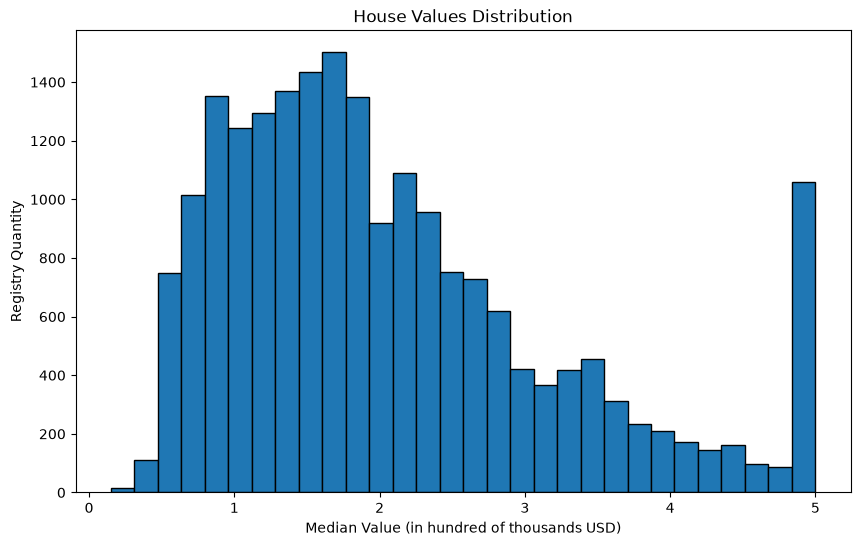

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(df["MedHouseVal"], bins=30, edgecolor="black")

plt.title("House Values Distribution")
plt.xlabel("Median Value (in hundred of thousands USD)")
plt.ylabel("Registry Quantity")

plt.show()

Insights:

- Most observations are **concentrated between approximately US$100,000 and US$200,000**. 

- Another notable concentration **appears near the upper limit of approximately US$500,000**.

- **This upper limit may affect both the distribution of the target variable and the model's predictions**.

### Median Income and House Values

Next, I will examine the relationship between median income (`MedInc`) and median house value (`MedHouseVal`).

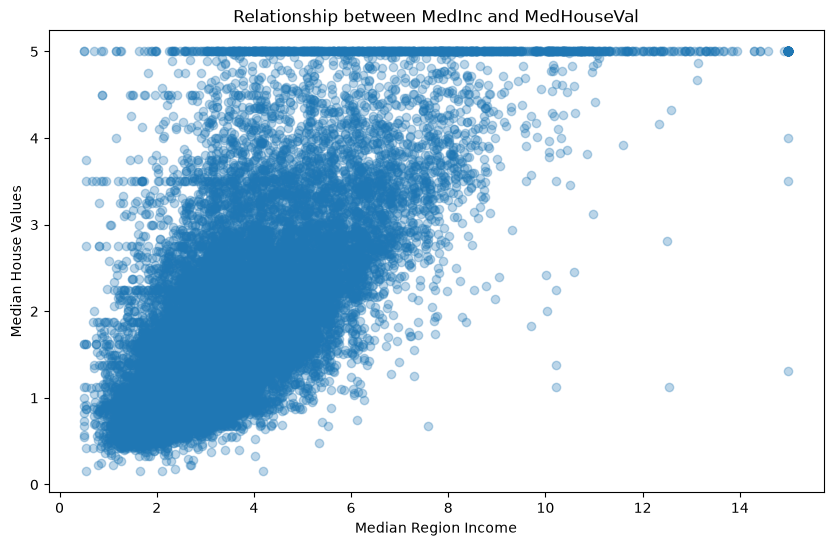

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.title("Relationship between MedInc and MedHouseVal")
plt.xlabel("Median Region Income")
plt.ylabel("Median House Values")

plt.show()

Insights:
- This suggests a **positive relationship** between **median income** and **house values**. Regions with **higher median incomes** tend to have **higher-valued houses**.
- However, the relationship **isn't perfectly linear**, indicating that **other variables may also influence house values**.

### Correlation matrix

I will examine the correlation matrix in order to identify any linear relationships between the features in the data, particularly with the target variable, and assess the strength and direction of these relationships.

Correlations will normally be between `-1`, `0` and `+1`. Normally, the closest to `+1` suggests a postive relationship, values close to `-1` suggests a negative relationship and the value being the closest to `0` suggest low linear relation.

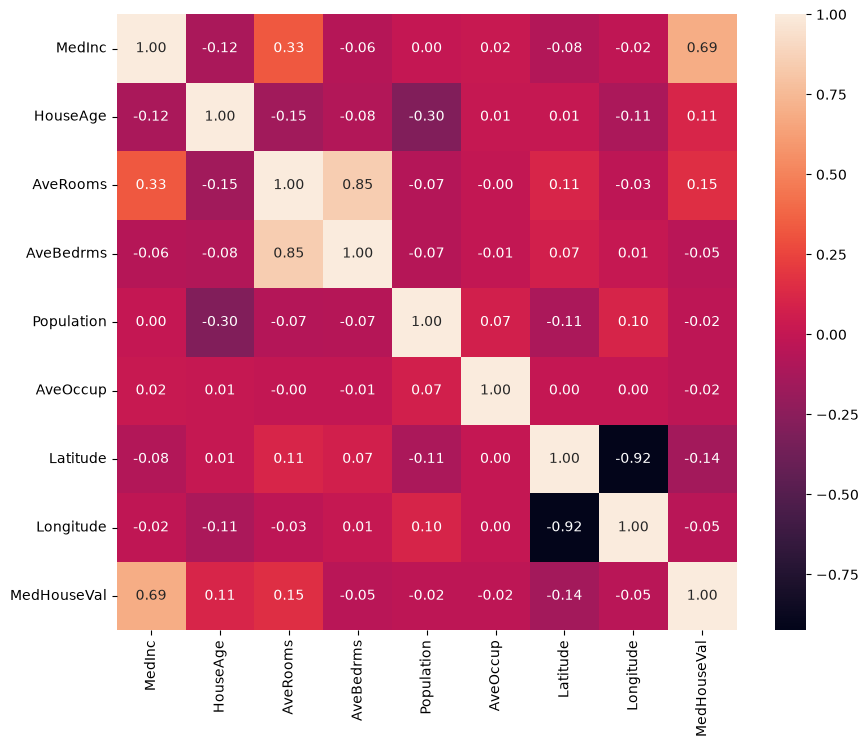

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.show()

Insights:
- `MedInc` showed the strongest correlation with `MedHouseVal`, reinforcing the relationship previously observed during the exploratory analysis. However, individual analysis may not always show every single one of the existing patterns in the data.
- The remaining features showed **weaker individual correlations**, suggesting that house values may be influenced by **multiple factors and potentially more complex relationships**.

### Geographic Distribution

Finally, I will examine the geographic distribution of house values using latitude and longitude.

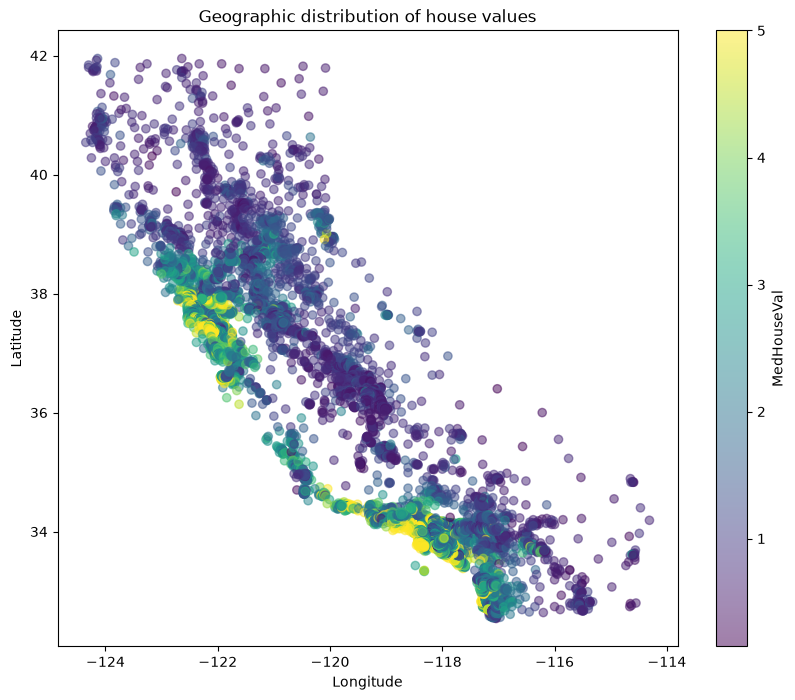

In [58]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    alpha=0.5
)

plt.colorbar(label="MedHouseVal")
plt.title("Geographic distribution of house values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Insights:
- House values **aren't randomly distributed** across California. The analysis suggests that **geographic location is associated with housing prices**, with some areas showing a higher concentration of more expensive properties.
- This indicates that location may provide useful information for predicting house values.

## EDA Conclusions

**Main insights:**

- Most house values distribution are concentrated between **approximately US$100,000 and US$200,000**. That indicates that most dataset regions have median house values within this range.
- **The house values distribution** near the upper limit of approximately **US$500,000 does not seem to be an common distribution behavior**. It may indicate that the **dataset does have an maximum limit of US$500,000**, which may affect both the **distribution of the target variable** and **the model's predictions** that will be performed.

# Real Estate Data Analysis

## 1. Objective

## 2. Methodology

## 3. Data Loading

## 4. Understanding the Dataset

### 4.1 Dataset Dimensions
### 4.2 Data Types and Missing Values
### 4.3 Descriptive Statistics

## 5. Exploratory Data Analysis

### 5.1 Distribution of House Values
### 5.2 Income vs. House Value
### 5.3 Correlation Analysis
### 5.4 Geographic Distribution

## 6. Machine Learning

### 6.1 Feature and Target Separation
### 6.2 Train/Test Split
### 6.3 Baseline
### 6.4 Linear Regression
### 6.5 Random Forest

## 7. Model Comparison

### 7.1 MAE Comparison
### 7.2 Actual vs. Predicted Values
### 7.3 Feature Importance

## 8. Results and Discussion

## 9. Conclusion

## 2. Metodologia

O projeto será desenvolvido nas seguintes etapas:

1. Carregamento dos dados
2. Entendimento e exploração dos dados
3. Limpeza e validação
4. Análise exploratória
5. Visualização dos dados
6. Desenvolvimento de um modelo de Machine Learning
7. Avaliação do modelo
8. Interpretação dos resultados

## 3. Conhecendo os Dados

- Quantas linhas e colunas existem?
20640
- Quais são as colunas?

MediumIncome (mediana do salário das pessoas do quarteirão)
HouseAge (Idade de um imóvel)
AverageRooms (Média de cômodos por casa)
AverageBedrooms (Média de quartos por casa)
Population (População por quarteirão)
AverageOccupation (Quantidade média de moradores por casa)
Latitude
Longitude
MediumHouseValue (mediana do valor das casas de um quarteirão)

- Que tipo de dado cada coluna possui?
Todos tipo Float ou inteiro
- Existem valores ausentes?
Não

In [3]:
from sklearn.datasets import fetch_california_housing
dados = fetch_california_housing(as_frame=True)

df = dados.frame
df.head()
# df.info()

# A nossa principal variável é:
# 🎯 MedHouseVal
# Ela representa o valor mediano das casas em determinada região.

# É essa variável que queremos:
# 1. Analisar;
# 2. Entender quais fatores possuem relação com ela;
# 3. Posteriormente tentar prever utilizando Machine Learning.
# As outras colunas serão as características que vamos investigar.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Análise Exploratória
### 4.1 Variável de Interesse

MedHouseVal

### 4.2 Distribuição dos Valores dos Imóveis

### Insight inicial

A maior concentração de valores dos imóveis está aproximadamente entre US$ 100 mil e US$ 200 mil.

Também foi identificado um comportamento incomum próximo ao valor máximo de US$ 500 mil, onde existe uma concentração significativa de registros.

Esse comportamento pode indicar uma limitação ou um teto nos valores presentes no dataset, algo que deverá ser considerado nas próximas etapas da análise.

Mostrando que a 📊 Maior concentração entre aproximadamente US$ 100 mil e US$ 200 mil

Isso indica que grande parte das regiões do dataset possui valores medianos de imóveis nessa faixa.

Outra coisa: a concentração no valor máximo não parece um comportamento natural da distribuição. Isso reforça nossa suspeita de que o dataset possui um limite máximo de US$ 500 mil (Limitação dos dados).

### 4.3 Relação entre Renda e Valor dos Imóveis

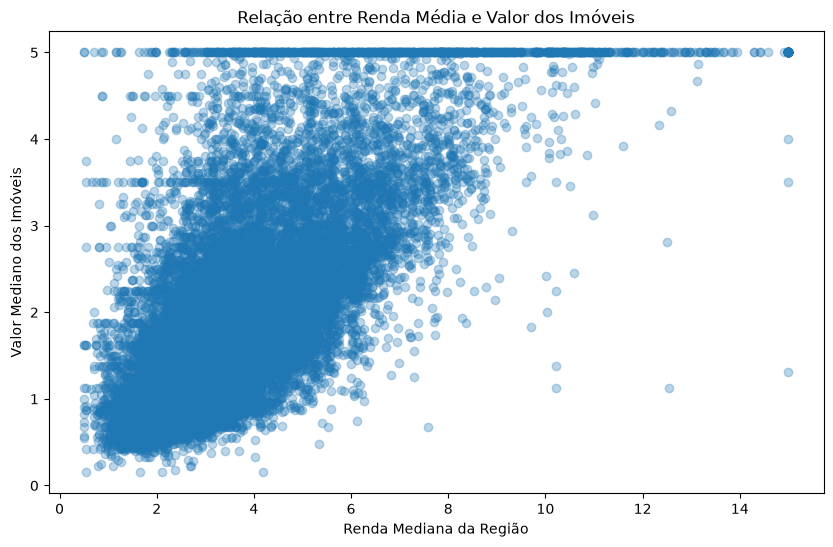

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.title("Relação entre Renda Média e Valor dos Imóveis")
plt.xlabel("Renda Mediana da Região")
plt.ylabel("Valor Mediano dos Imóveis")

plt.show()

Ah sim, quanto mais subimos para regioes mais ricas, o valor dos imoveis sobe

Regiões com maior renda mediana tendem a apresentar imóveis com maior valor mediano.

### 4.4 Correlação entre as Variáveis
Até agora estamos olhando para gráficos. Agora quero te apresentar uma ferramenta muito importante em análise de dados: correlação (df.corr()).
Ela nos ajuda a quantificar o quanto duas variáveis estão relacionadas.

A correlação geralmente fica entre:
-1  ←──────── 0 ────────→  +1

De maneira simplificada:
- próximo de +1: relação positiva;
- próximo de -1: relação negativa;
- próximo de 0: pouca relação linear.

renda ↑  → preço ↑
correlação positiva
X ↑ → Y ↓
correlação negativa
-> correlação mede associação, não prova causa.

A variável com a correlação mais forte com MedHouseVal é:
MedInc: 0.688
Regiões com maior renda mediana tendem a apresentar valores medianos de imóveis mais elevados.

In [6]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


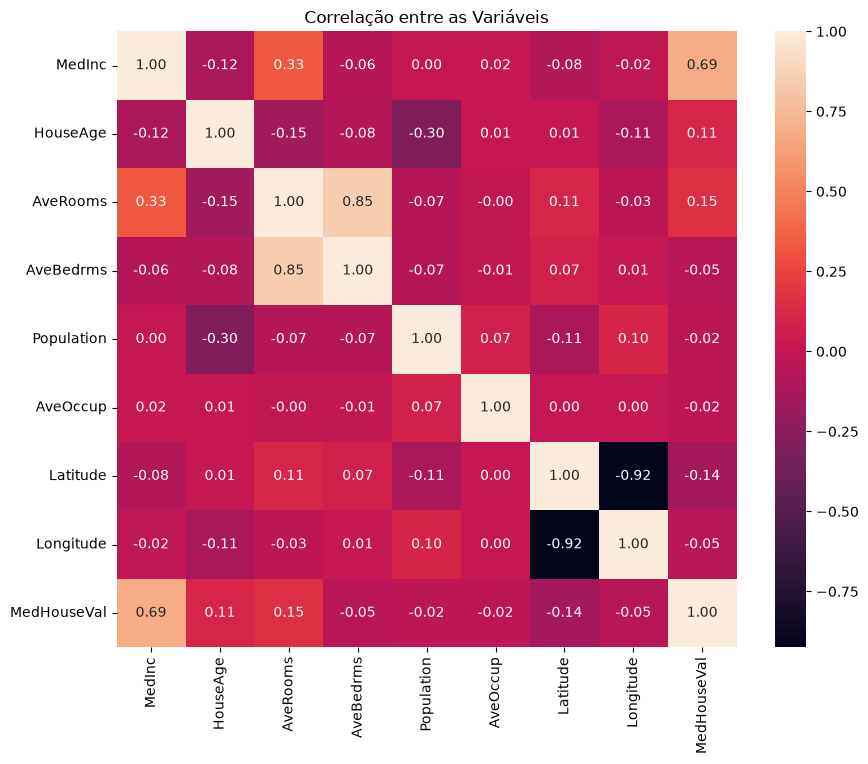

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlação entre as Variáveis")

plt.show()

A renda mediana (MedInc) apresenta, de longe, a relação linear mais forte com o valor mediano dos imóveis (MedHouseVal).

Porém, análise individual de variáveis nem sempre mostra todo o padrão existente nos dados.

### 4.5 Localização Geográfica e Valor dos Imóveis

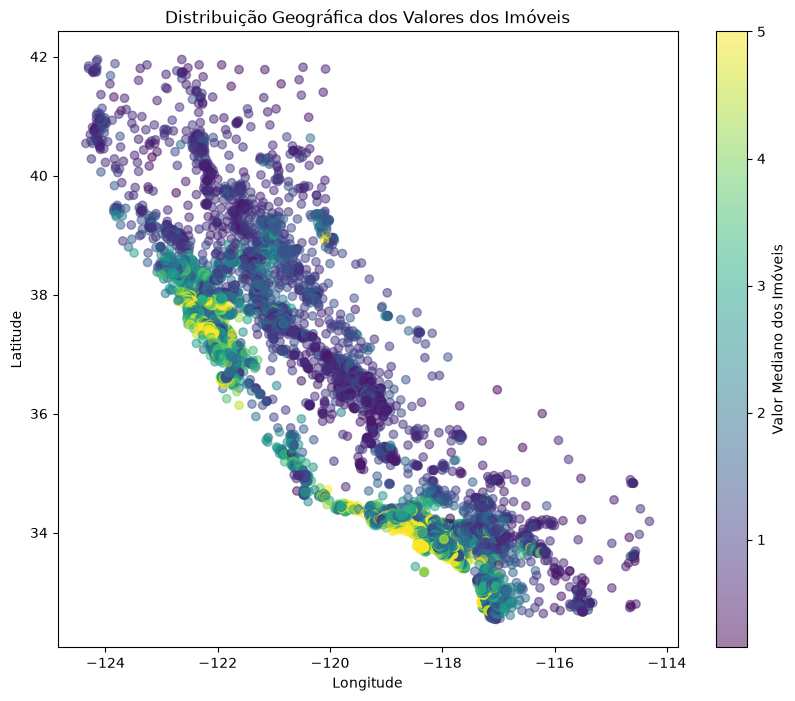

In [8]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    alpha=0.5
)

plt.colorbar(label="Valor Mediano dos Imóveis")
plt.title("Distribuição Geográfica dos Valores dos Imóveis")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

🗺️ Sobre o formato do gráfico
Sim, ele lembra o formato da Califórnia porque os dados possuem coordenadas reais de regiões do estado:
- Longitude → posição horizontal;
- Latitude → posição vertical.
Então, ao combinar as duas variáveis, acabamos criando uma representação geográfica simplificada da distribuição dos registros.

Observou-se que regiões próximas à costa aparentam possuir uma concentração maior de imóveis com valores elevados.

O gráfico indica que os valores não estão distribuídos aleatoriamente pelo território. Existem áreas específicas com maior concentração de valores elevados.

Isso também ajuda a entender algo que vimos anteriormente:
As variáveis de Latitude e Longitude, analisadas individualmente, apresentavam correlações relativamente fracas com MedHouseVal, mas quando combinamos as duas variáveis como localização, aparece um padrão muito mais claro.

### Insight sobre localização

A distribuição dos valores dos imóveis apresenta um padrão geográfico e não ocorre de forma aleatória.

Regiões próximas à costa aparentam concentrar uma quantidade maior de imóveis com valores elevados, enquanto outras regiões apresentam predominantemente valores mais baixos.

Essa análise também mostra que latitude e longitude, quando analisadas conjuntamente, podem fornecer informações mais relevantes do que quando avaliadas isoladamente.

Mas a partir de tudo isso, como conseguimos utilizar essas características para estimar o valor dos imóveis?

Antes de treinar qualquer modelo de ML para responder isso, vamos entender uma estrutura fundamental:

(Variáveis)
Características → Modelo → Previsão
       X             ↓        ŷ

Valor real → Comparação
     y

Valor que queremos prever (y): MedHouseVal

Agora, devemos começar a responder:
É possível estimar o valor dos imóveis utilizando as características disponíveis?

Para isso, vamos separar o DataFrame.

(y) target: MedHouseVal
(x) nformações usadas para fazer a previsão (tudo menos o y)

## 6. Preparação para Machine Learning:

In [10]:
x = df.drop(columns="MedHouseVal")

y = df["MedHouseVal"]

print("Dimensão de X:", x.shape)
print("Dimensão de y:", y.shape)

x.head()

Dimensão de X: (20640, 8)
Dimensão de y: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


No nosso caso:

X
├── MedInc
├── HouseAge
├── AveRooms
├── AveBedrms
├── Population
├── AveOccup
├── Latitude
└── Longitude

y
└── MedHouseVal

X → informações para fazer a previsão
y → resposta que queremos prever

### 6.1 Separação dos Dados


A partir do resultado dos códigos anteriores, você poderia pensar: "Tenho 20.640 linhas. Por que não simplesmente mando todas para o modelo aprender?"

O problema é que precisamos descobrir se o modelo realmente aprendeu a "generalizar" ou simplesmente ficou bom em prever os dados que já viu. Por exemplo:

Imagine um aluno estudando para uma prova. Suponha que o professor deu 100 exercícios para o aluno. O aluno estuda todos os exercícios.

Depois o professor aplica ao aluno exatamente os mesmos 100 exercícios e o aluno acerta 100%.

Pergunta: Posso concluir que o aluno realmente aprendeu?
Resposta: Não necessariamente. Ele pode simplesmente ter decorado as respostas.

Agora imagina: O aluno tem 100 exercícios para estudar, mas a prova tem exercícios diferentes.

Então: se ele tiver um bom desempenho na prova nova, temos uma evidência muito melhor de que ele realmente aprendeu o conteúdo. E o Machine Learning funciona de forma parecida. 

Precisamos separar:

Dados disponíveis
       ↓
 ┌───────────────┐
 │               │
Treinamento    Teste
   ~80%          ~20%
 │               │
 ↓               ↓
modelo          avaliação

O modelo só pode aprender com os dados de treinamento.
Depois usamos dados que ele nunca viu durante o treinamento para avaliar sua capacidade de fazer previsões.

Isso se chama Train/Test Split.

In [11]:
# Train/Test Split 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2, # Estamos dizendo: separe 20% dos dados para teste. Consequentemente 80% → treinamento e 20% → teste
    random_state=42 # o Train/Test Split precisa embaralhar e escolher aleatoriamente quais registros vão para treinamento e teste. Se você executar o código novamente sem controlar essa aleatoriedade, poderá obter uma divisão diferente. O random_state=42 faz com que a divisão seja reproduzível. Não existe nada de especial no número 42. Poderíamos utilizar outro número. O importante é manter o mesmo valor quando queremos reproduzir o experimento.
)

print(f"Dados de treinamento: {x_train.shape}")
print(f"Dados de teste: {x_test.shape}")

Dados de treinamento: (16512, 8)
Dados de teste: (4128, 8)


E guarde este conceito. Essa divisão (treinamento e teste) não é uma formalidade. Estamos tentando responder duas perguntas diferentes:

Treinamento:
"O modelo consegue aprender uma relação entre as características e o preço?"

Teste:
"Depois de aprender, ele consegue utilizar essa relação para prever preços que nunca viu?"

Essa segunda pergunta é fundamental. Porque o objetivo de Machine Learning não é memorizar nossos 20.640 registros. É aprender padrões que possam ser utilizados em novos dados.

### 6.2 Criando uma Baseline

O que é uma baseline? Uma baseline é uma solução simples para termos de referência com o desempenho do nosso modelo, com o objetivo de que ele seja melhor que a solução simples.

Isso responde à pergunta:
"Um modelo de Machine Learning realmente consegue fazer melhor do que uma estratégia extremamente simples?"

No nosso caso, vamos utilizar uma estratégia simples: Sempre prever o valor médio dos imóveis presentes nos dados de treinamento.

Exemplo:
Imagine que esses são os valores de imóveis:
100
150
200
250
300

A média dos valores é: 200
Então nossa baseline poderia simplesmente prever esses valores de imóveis:
200
200
200
200
200

Nossa baseline não conhece:
- renda;
- localização;
- idade das casas;
- quantidade de cômodos.
Essa baseline simplesmente utiliza a média como previsão para tudo.

Naturalmente, não esperamos que essa seja uma estratégia excelente, mas agora temos uma referência. Se nosso modelo de Machine Learning não conseguir fazer melhor que isso, temos um problema. 😅

Uma observação importante: a baseline também só pode aprender com os dados de treinamento. Não vamos calcular a média utilizando todos os dados:

# Não vamos fazer isso
y.mean()

Por quê?
Porque estaríamos utilizando informações do conjunto de teste.
Lembre-se:

Treinamento → o modelo pode conhecer
Teste       → o modelo não pode conhecer

In [13]:
baseline_prediction = y_train.mean()

print(f"Previsão da baseline: {baseline_prediction:.2f}")
# Esse valor representa a média dos valores dos imóveis presentes apenas no conjunto de treinamento.
# Mas ainda precisamos responder: Qual é o erro dessa baseline?

Previsão da baseline: 2.07


Conhecendo uma métrica: MAE
Vamos utilizar inicialmente o MAE — Mean Absolute Error.
Em português:
Erro Médio Absoluto

A ideia é simples.
Para cada previsão:
Valor real:     3.00
Previsão:       2.00
Diferença:      1.00

Em outro registro:
Valor real:     1.50
Previsão:       2.00
Diferença:      0.50

Calculamos essas diferenças em valor absoluto e depois tiramos a média.
Por isso: MAE menor = melhor

Para isso, importaremos a seguinte métrica do scikit-learn, para criar uma previsão para cada registro de teste: MAE (mean_absolute_error)
Nossa baseline prevê sempre a mesma coisa, então:

In [14]:
from sklearn.metrics import mean_absolute_error # MAE
baseline_predictions = [baseline_prediction] * len(y_test)
# Isso cria uma lista com a média repetida para cada imóvel do conjunto de teste.
# Agora calculamos:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

print(f"MAE da baseline: {baseline_mae:.2f}") # resulta 0.91, ou seja: erro medio aprox. US$ 91.000

# O que acabou de acontecer?
# Criamos nosso primeiro ponto de referência numérico.
# A partir de agora, poderemos comparar:

# Baseline:
# MAE = X

# Modelo 1:
# MAE = ?

# Modelo 2:
# MAE = ?

# E então responder objetivamente:
# O modelo realmente melhorou em relação a uma estratégia simples?

MAE da baseline: 0.91


A partir de agora, qualquer modelo que treinarmos terá uma missão:
Fazer previsões melhores do que a baseline.

Por exemplo:
Baseline → MAE: 0.91

Modelo A → MAE: 0.65

Quanto menor o MAE, menor é o erro médio.

-//-

Uma observação importante para o projeto: por enquanto, não vamos decidir se 0.91 (US$ 91 mil) é um erro "bom" ou "ruim" isoladamente.

O principal valor da baseline é servir como referência comparativa. Quando treinarmos nosso primeiro modelo, veremos quantitativamente quanto conseguimos melhorar em relação a essa estratégia simples.

-//-

Agora sim, com uma referência estabelecida, o próximo passo natural será treinar nosso primeiro modelo de verdade — uma Regressão Linear

### 6.3 Primeiro Modelo: Regressão Linear 📈
A ideia da Regressão Linear é tentar encontrar relações entre nossas características e o valor que queremos prever.

Simplificando:

Renda
Idade das casas
Localização
Quantidade de cômodos
        ↓
   Modelo aprende
        ↓
Valor previsto

O modelo tentará aprender como essas características se relacionam com MedHouseVal.

Estrutura: 
x_train → informações de entrada
y_train → respostas corretas
        ↓
      modelo
        ↓
aprende padrões e relações

O modelo recebe os dados de treinamento e tenta encontrar relações entre as características de x_train e os valores de y_train.
(Nao utilizamos as nomenclaturas x e y no lugar de x_train e y_train porque queremos preservar os dados de teste para uma avaliação honesta.)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() # instancia
model.fit(x_train, y_train) # treinamento
y_pred = model.predict(x_test)
# o modelo recebe x_test e gera y_pred, características de regiões que ele nunca viu durante o treinamento.

Quando dizemos que o modelo recebe uma "região que nunca viu", queremos dizer que ele está recebendo uma combinação de características pertencente a uma observação que não estava no conjunto de treinamento.

Por que cada linha do nosso dataset representa uma observação de uma região. Por exemplo, simplificando:

Região A
├── MedInc: 3.5
├── HouseAge: 20
├── AveRooms: 5.2
├── Population: 1.200
├── Latitude: 34.2
├── Longitude: -118.4
└── MedHouseVal: 2.5

Quando fizemos o train_test_split, uma parte dessas observações foi separada aleatoriamente (80/20):

20.640 regiões/observações
          │
          ▼
   train_test_split
       │       │
       ▼       ▼
   Treinamento  Teste
    16.512       4.128

Então o modelo foi treinado com 16.512 registros e nunca recebeu as 4.128 observações específicas do conjunto de teste durante o treinamento.

Por exemplo:

(durante o treinamento)
Renda: 4.0
Idade: 25
Latitude: 34.0
Longitude: -118.2
Preço: 3.2

(durante o teste)
Renda: 6.0
Idade: 15
Latitude: 37.5
Longitude: -122.4
Preço: ???

Já durante a previsão, o modelo recebe apenas:

Renda: 6.0
Idade: 15
Latitude: 37.5
Longitude: -122.4
...

Ele não recebe o MedHouseVal.

O ponto principal é:
As linhas específicas presentes em X_test não foram utilizadas pelo modelo durante o treinamento. Essa é uma distinção muito importante.

O modelo utiliza os padrões aprendidos durante o treinamento para tentar responder: "Com base nas características que aprendi anteriormente, qual valor eu estimaria para este imóvel/região?"

Só depois que comparamos a previsão com o valor real que estava guardado em y_test.

In [18]:
# previsoes

print("Valores reais:")
print(y_test.head())

print("\nPrevisões:")
print(y_pred[:5])

Valores reais:
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
Name: MedHouseVal, dtype: float64

Previsões:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


E olhando para os  resultados, já é possível perceber que algumas previsões estão próximas e outras parecem ter erros consideráveis.


### 6.4 Avaliação do Modelo
Vamo utilizar MAE e calcular a diferença entre os valores reais e valores previstos pelo modelo para todas as 4.128 observações de teste para encontrar o erro médio absoluto. 

In [19]:
from sklearn.metrics import mean_absolute_error
model_mae = mean_absolute_error(y_test, y_pred)
# y_test → valores reais
# y_pred → valores previstos pelo modelo
# mean_absolute_error() calcula a diferença entre eles para todas as 4.128 observações de teste e encontra o erro médio absoluto.

print(f"MAE da baseline: {baseline_mae:.2f}")
print(f"MAE da Regressão Linear: {model_mae:.2f}")

MAE da baseline: 0.91
MAE da Regressão Linear: 0.53


In [21]:
improvement = (
    (baseline_mae - model_mae) / baseline_mae
) * 100

print(f"Redução do erro: {improvement:.2f}%")

Redução do erro: 41.15%


Um resultado de 0.53 (R$ 53 mil dólares de erro médio aproximado), comparado com 0.91 (R$ 91 mil dólares de erro médio aproximado) da baseline significa que o modelo conseguiu aprender padrões nos dados e reduzir significativamente o erro em comparação com simplesmente prever a média para todas as regiões.

A Regressão Linear reduziu o erro em aproximadamente 41,15%.

Contudo, não devemos concluir que a Regressão Linear é nosso melhor modelo apenas porque foi o primeiro que testamos.

### 6.5 Segundo Modelo: Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100, # árvores de decisão
    random_state=42
)

In [24]:
# Agora treinamos
random_forest.fit(x_train, y_train)

# Fazemos as previsões
rf_predictions = random_forest.predict(x_test)

# e calculamos o MAE:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

# E vamos comparar os três:

print(f"Baseline: {baseline_mae:.2f}")
print(f"Regressão Linear: {model_mae:.2f}")
print(f"Random Forest: {rf_mae:.2f}")

Baseline: 0.91
Regressão Linear: 0.53
Random Forest: 0.33


Com esses resultados sabemos que Random Forest reduziu o erro em cerca de 64% em relação à baseline e aproximadamente 38% em relação à Regressão Linear.

Random Forest
      ↓
Comparar resultados
      ↓
Visualizar previsões × valores reais
      ↓
Criar uma tabela final de resultados
      ↓
Interpretar o melhor modelo
      ↓
Conclusão do projeto

### 6.6 Comparação dos Modelos

In [25]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        model_mae,
        rf_mae
    ]
})

results

,Model,MAE
0,Baseline,0.906069
1,Linear Regression,0.533200
2,Random Forest,0.327843


In [26]:
# Agora vamos adicionar uma coluna com o erro aproximado em dólares:

results["Error (USD)"] = results["MAE"] * 100000

results

,Model,MAE,Error (USD)
0,Baseline,0.906069,90606.854900
1,Linear Regression,0.533200,53320.013050
2,Random Forest,0.327843,32784.343772


In [27]:
# Para facilitar a leitura:

results["Error (USD)"] = results["Error (USD)"].round(2)

results

,Model,MAE,Error (USD)
0,Baseline,0.906069,90606.85
1,Linear Regression,0.533200,53320.01
2,Random Forest,0.327843,32784.34


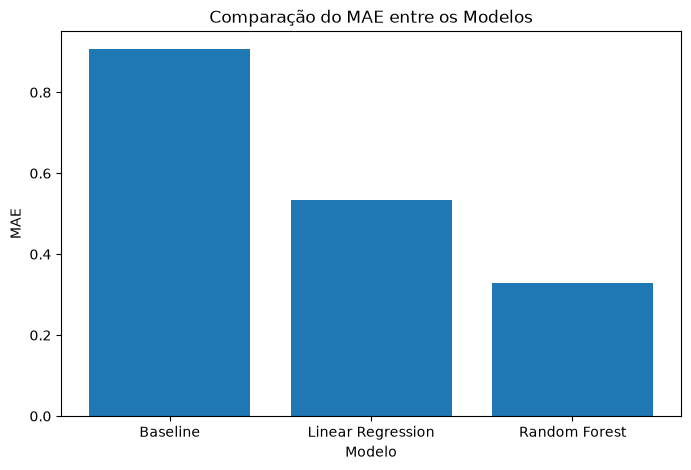

In [28]:
# Vamos visualizar essa comparação:

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("Comparação do MAE entre os Modelos")
plt.xlabel("Modelo")
plt.ylabel("MAE")

plt.show()

Temos:
Baseline       → 0.906069
Linear         → 0.533200
Random Forest  → 0.327843

O Random Forest apresentou o menor erro médio entre todas as abordagens testadas.

### 7.1 Improvement over Baseline

In [29]:
rf_improvement = (
    (baseline_mae - rf_mae) / baseline_mae
) * 100

print(f"Reduction in error: {rf_improvement:.2f}%")

Reduction in error: 63.82%


O Random Forest reduziu o erro médio absoluto em aproximadamente 63,8% em relação à baseline.

E comparando com a Regressão Linear:

In [30]:
lr_improvement = (
    (model_mae - rf_mae) / model_mae
) * 100

print(f"Reduction compared to Linear Regression: {lr_improvement:.2f}%")

Reduction compared to Linear Regression: 38.51%


Apresentou 38,51% de redução.

### 7.2 Actual vs. Predicted Values

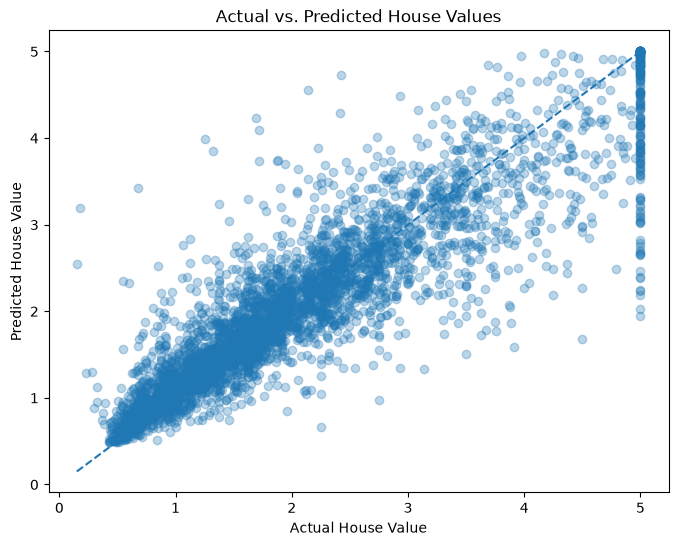

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs. Predicted House Values")

plt.show()

No nosso gráfico, os pontos acompanham claramente essa tendência diagonal.
Isso é um bom sinal: conforme o valor real aumenta, o modelo geralmente também aumenta sua previsão.

### Feature Importance

In [32]:
random_forest.feature_importances_ # importância relativa para cada variável

array([0.52495507, 0.05466414, 0.04420161, 0.0296645 , 0.03062603,
       0.13838313, 0.08887883, 0.0886267 ])

In [33]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance # (em porcentagens)

,Feature,Importance
0,MedInc,0.524955
5,AveOccup,0.138383
6,Latitude,0.088879
7,Longitude,0.088627
1,HouseAge,0.054664
2,AveRooms,0.044202
4,Population,0.030626
3,AveBedrms,0.029665


MedInc sozinha representa aproximadamente 52,5% da importância atribuída pelo modelo.

E isso conversa diretamente com aquilo que encontramos na EDA: MedInc foi a variável que apresentou a maior correlação com MedHouseVal.

EDA
↓
MedInc apresentou forte relação com MedHouseVal
↓
Machine Learning
↓
Random Forest também atribuiu a maior importância a MedInc

A localizacao também é algo interessante: 
Latitude   → 8,89%
Longitude  → 8,86%

Individualmente, as correlações lineares dessas variáveis não eram tão fortes. Porém, o Random Forest atribuiu importância considerável às duas em conjunto.
Isso reforça uma ideia que já apareceu na nossa análise geográfica: a localização contém informação relevante para estimar o valor dos imóveis, mesmo que uma correlação linear isolada não conte toda a história.
Só cuidado com uma coisa no texto final: feature_importances_ mostra importância relativa usada pelo Random Forest, não significa que "52,5% do preço é explicado pela renda". É uma distinção importante.

### 7.4 Model Improvement

In [34]:
rf_improvement = (
    (baseline_mae - rf_mae) / baseline_mae
) * 100

print(f"Reduction in error compared to baseline: {rf_improvement:.2f}%")

Reduction in error compared to baseline: 63.82%


In [38]:
rf_vs_linear = (
    (model_mae - rf_mae) / model_mae
) * 100

print(f"Reduction compared to Linear Regression: {rf_vs_linear:.2f}%")

Reduction compared to Linear Regression: 38.51%


Nossa evolução ficou:
Baseline
MAE = 0.906
       ↓
       ↓ -41,2%
       ↓
Linear Regression
MAE = 0.533
       ↓
       ↓ -38,5%
       ↓
Random Forest
MAE = 0.328

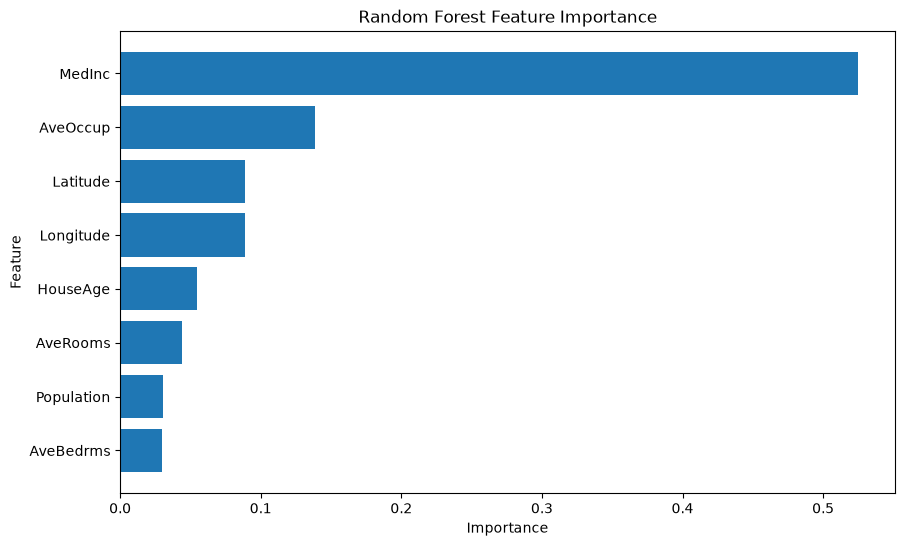

In [36]:
# Feature Importante Graphic

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Problema
Investigar quais características estão associadas ao valor dos imóveis.
EDA
Encontramos padrões em renda e localização.
Baseline
MAE de 0.906.
Linear Regression
MAE de 0.533.
Random Forest
MAE de 0.328.
Resultado
Random Forest apresentou o menor erro.
Interpretação
MedInc foi a característica mais importante, seguida por AveOccup e pelas variáveis geográficas.

storytelling técnico
Exploração dos dados
        ↓
MedInc apresentou a relação mais forte com MedHouseVal
        ↓
A localização também apresentou padrões relevantes
        ↓
Criamos uma baseline simples
MAE = 0.91
        ↓
Linear Regression
MAE = 0.53
        ↓
Random Forest
MAE = 0.33
        ↓
Redução de 63.82% no erro em relação à baseline
        ↓
Feature Importance
        ↓
MedInc foi novamente a variável mais importante

ordem noteboook:

1. Objective
   └── O que queremos investigar?

2. Methodology
   └── Como vamos investigar?

3. Data Loading
   └── Carregamento e criação do DataFrame

4. Dataset Overview
   ├── Dimensões
   ├── Tipos de dados
   ├── Valores ausentes
   └── Estatísticas descritivas

5. Exploratory Data Analysis
   ├── Distribuição dos preços
   ├── Relação entre renda e preço
   ├── Correlações
   └── Distribuição geográfica

6. Data Preparation
   ├── Separação entre x e y
   └── Train/Test Split

7. Modeling
   ├── Baseline
   ├── Linear Regression
   └── Random Forest

8. Results and Model Evaluation
   ├── Comparação dos MAEs
   ├── Gráfico de comparação
   ├── Actual vs. Predicted
   ├── Improvement over Baseline
   └── Feature Importance

9. Limitations

10. Conclusion

Eu recebi um dataset → explorei os dados → identifiquei padrões → preparei os dados → criei uma referência → testei modelos → comparei resultados → interpretei as descobertas e reconheci as limitações.

## 8. Results and Discussion

The machine learning models showed a significant improvement over the baseline approach.

The baseline, which predicted the average house value for every observation, achieved a Mean Absolute Error (MAE) of approximately 0.91, corresponding to an average error of about US$90,607.

The Linear Regression model reduced the MAE to approximately 0.53, while the Random Forest achieved the best performance, with an MAE of approximately 0.33, corresponding to an average prediction error of about US$32,784.

Compared to the baseline, the Random Forest reduced the prediction error by approximately 63.82%. It also reduced the error by approximately 38.51% compared to the Linear Regression model.

The feature importance analysis also reinforced findings from the exploratory data analysis. MedInc was the most important feature for the Random Forest model, followed by AveOccup and the geographic variables Latitude and Longitude.

## 9. Limitations

This project has some limitations that should be considered when interpreting the results.

- The analysis is based on a historical dataset and may not represent current housing market conditions.
- The target variable has an apparent upper limit around US$500,000, which may affect the distribution of the data and the model's predictions.
- The dataset contains aggregated information about housing areas rather than detailed information about individual properties.
- The models were evaluated using a single train/test split and limited hyperparameter tuning.

## 10. Conclusion

This project explored the relationship between socioeconomic, demographic, and geographic characteristics and house values in California.

The exploratory analysis identified median income as the variable most strongly associated with house values, while geographic patterns suggested that location also played an important role.

The machine learning experiments demonstrated that using these features provided a substantial improvement over a simple baseline approach. Among the evaluated models, the Random Forest achieved the best performance, reducing the Mean Absolute Error by approximately 63.82% compared to the baseline.

The feature importance analysis reinforced the exploratory findings, with median income being the most important feature for the model. Geographic variables also showed relevant importance, highlighting the contribution of location to housing value predictions.

Overall, this project demonstrates how exploratory data analysis and machine learning can be combined to investigate patterns in real-world data and build predictive models.

In [12]:
df["MedHouseVal"].describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [ ]:
df["MedHouseVal"].value_counts()

MedHouseVal
5.00001    965
1.37500    122
1.62500    117
1.12500    103
1.87500     93
          ... 
4.22900      1
3.49400      1
4.25800      1
2.00700      1
0.47000      1
Name: count, Length: 3842, dtype: int64

In [ ]:
linhas, colunas = df.shape

print(f"Quantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")

Quantidade de linhas: 20640
Quantidade de colunas: 9


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
print(dados.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g